In [1]:
import pandas as pd

data = {
    "order_id":[1,2,3,4,5,6,7,8,9,10],
    "customer_id":[101,102,103,101,104,102,105,103,101,104],
    "product":["Laptop","Phone","Mouse","Laptop","Tablet","Phone","Mouse","Tablet","Laptop","Phone"],
    "quantity":[1,2,5,1,3,1,2,2,1,1],
    "price":[50000,20000,500,50000,15000,20000,500,15000,50000,20000]
}

df = pd.DataFrame(data)

In [2]:
df["revenue"] = df["quantity"] * df["price"]

In [3]:
df["revenue"].sum()

np.int64(308500)

In [4]:
df.groupby("product")["revenue"].sum()

product
Laptop    150000
Mouse       3500
Phone      80000
Tablet     75000
Name: revenue, dtype: int64

In [5]:
df.groupby("product")["revenue"].sum().sort_values(ascending=False)

product
Laptop    150000
Phone      80000
Tablet     75000
Mouse       3500
Name: revenue, dtype: int64

In [6]:
df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)

customer_id
101    150000
104     65000
102     60000
103     32500
105      1000
Name: revenue, dtype: int64

In [7]:
df.groupby("product")["quantity"].sum().sort_values(ascending=False)

product
Mouse     7
Tablet    5
Phone     4
Laptop    3
Name: quantity, dtype: int64

In [8]:
df["date"] = [
    "2024-01-01","2024-01-02","2024-01-03","2024-01-04","2024-01-05",
    "2024-01-06","2024-01-07","2024-01-08","2024-01-09","2024-01-10"
]

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df.groupby("date")["revenue"].sum()

date
2024-01-01    50000
2024-01-02    40000
2024-01-03     2500
2024-01-04    50000
2024-01-05    45000
2024-01-06    20000
2024-01-07     1000
2024-01-08    30000
2024-01-09    50000
2024-01-10    20000
Name: revenue, dtype: int64

In [12]:
customer_revenue=df.groupby("customer_id")["revenue"].sum()

In [13]:
def segment(x):
    if x>100000:
        return "high"
    elif x>=50000:
        return "medium"
    else:
        return "low"
customer_segment=customer_revenue.apply(segment)
print(customer_segment)

customer_id
101      high
102    medium
103       low
104    medium
105       low
Name: revenue, dtype: object


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

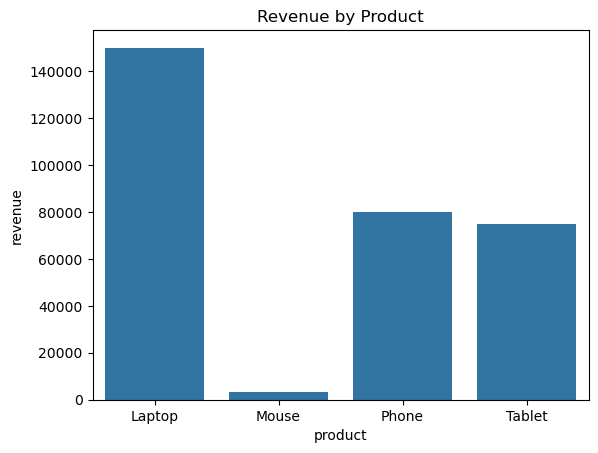

In [18]:
product_rev = df.groupby("product")["revenue"].sum().reset_index()

sns.barplot(x="product", y="revenue", data=product_rev)
plt.title("Revenue by Product")
plt.show()

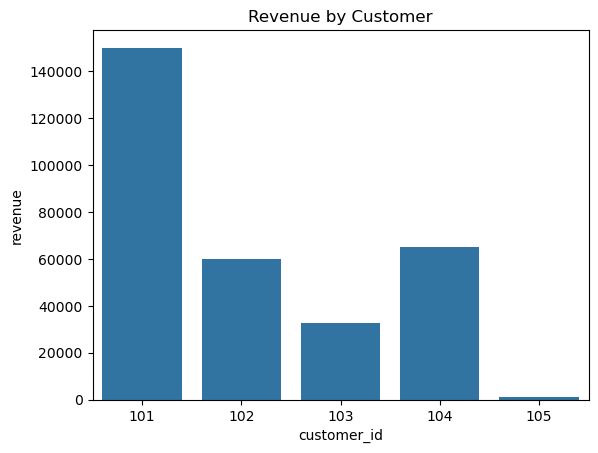

In [19]:
customer_rev = df.groupby("customer_id")["revenue"].sum().reset_index()

sns.barplot(x="customer_id", y="revenue", data=customer_rev)
plt.title("Revenue by Customer")
plt.show()

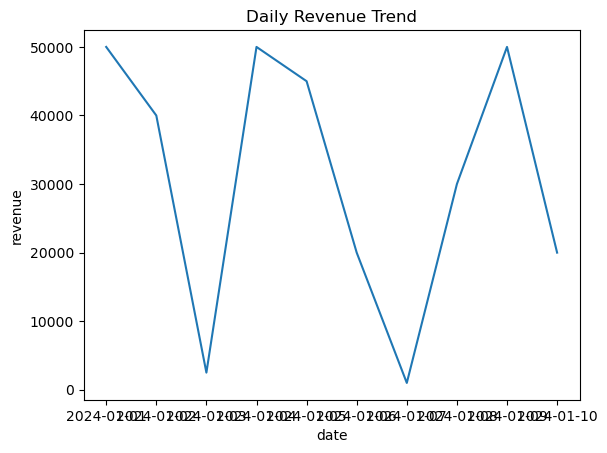

In [20]:
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

sns.lineplot(x="date", y="revenue", data=daily_rev)
plt.title("Daily Revenue Trend")
plt.show()